In [1]:
import tensorflow as tf
tf.__version__
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
tf.config.set_visible_devices(gpus[1], "GPU")


2024-12-07 10:44:56.226624: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1733539496.249982   26523 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1733539496.257178   26523 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-07 10:44:56.283082: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
import numpy as np

np.stack([np.random.randn(5).reshape(5).reshape(5,1).reshape(5), 
np.random.randn(5).reshape(5).reshape(5,1).reshape(5)])


array([[ 1.47948802,  0.99822727, -0.95638518, -1.47784071,  0.38362904],
       [-1.4210795 , -0.34665677, -0.78462516, -0.7201532 , -0.62988032]])

In [16]:
data = tf.random.normal((3,3))
print(data)
idx = tf.random.shuffle(tf.range(3))
print(idx)
print(tf.gather(data, idx))
print(tf.transpose(data))

tf.Tensor(
[[ 0.5383679   0.2604863  -0.8485892 ]
 [ 0.7607709  -0.99327785 -0.3331311 ]
 [ 0.0624269  -1.2915107  -1.596325  ]], shape=(3, 3), dtype=float32)
tf.Tensor([1 0 2], shape=(3,), dtype=int32)
tf.Tensor(
[[ 0.7607709  -0.99327785 -0.3331311 ]
 [ 0.5383679   0.2604863  -0.8485892 ]
 [ 0.0624269  -1.2915107  -1.596325  ]], shape=(3, 3), dtype=float32)
tf.Tensor(
[[ 0.5383679   0.7607709   0.0624269 ]
 [ 0.2604863  -0.99327785 -1.2915107 ]
 [-0.8485892  -0.3331311  -1.596325  ]], shape=(3, 3), dtype=float32)


In [8]:
tf.gather(tf.range(3), tf.random.shuffle(tf.range(3)))

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([2, 1, 0], dtype=int32)>

In [85]:
tf.reduce_mean(np.random.normal(size=5))

<tf.Tensor: shape=(), dtype=float64, numpy=-0.26302270444041137>

(3, 4)


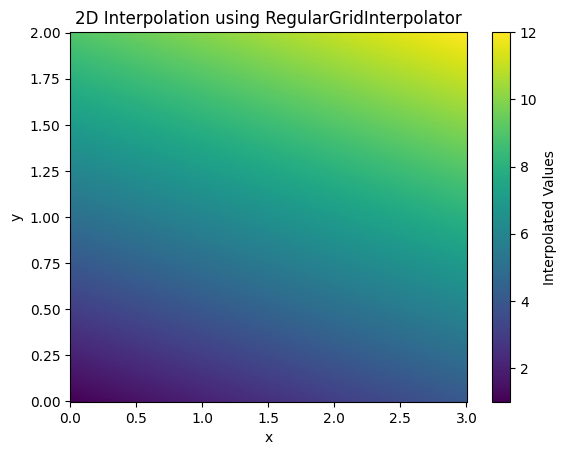

In [75]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt

# Define the grid points
x = np.array([0, 1, 2, 3])
y = np.array([0, 1, 2])
z = np.array([
    [1, 2, 3, 4],  # z-values at y=0
    [5, 6, 7, 8],  # z-values at y=1
    [9, 10, 11, 12]  # z-values at y=2
])

print(z.shape)

# Create the interpolation function
f = RegularGridInterpolator((y, x), z)

# Interpolate at new points
x_new = np.linspace(0, 3, 500)
y_new = np.linspace(0, 2, 300)
x_grid, y_grid = np.meshgrid(x_new, y_new)
z_new = f((y_grid, x_grid))  # Note: order is (y, x)

# Plot the result
plt.pcolormesh(x_new, y_new, z_new, shading='auto', cmap='viridis')
plt.colorbar(label='Interpolated Values')
plt.xlabel('x')
plt.ylabel('y')
plt.title('2D Interpolation using RegularGridInterpolator')
plt.show()

In [80]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np
def f(x, y, z):
    return 2 * x**3 + 3 * y**2 - z
x = np.linspace(1, 4, 11)
y = np.linspace(4, 7, 22)
z = np.linspace(7, 9, 33)
xg, yg ,zg = np.meshgrid(x, y, z, sparse=True)
data = f(xg, yg, zg)

In [83]:
zg.shape

(1, 1, 33)

In [81]:
yg.shape

(22, 1, 1)

In [82]:
data.shape

(22, 11, 33)

In [62]:
import numpy as np
import tensorflow as tf
from src import functions
H_function = functions.functions("1D_Gauss_mix")

y = tf.convert_to_tensor(np.random.normal(size=(50,1)), dtype=tf.float32)
x = tf.convert_to_tensor(np.random.normal(size=(100,1)), dtype=tf.float32)
# x = tf.constant([1], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(x)
    # z = x + 1 
    # z = tf.matmul(tf.transpose(x), x)
    # z = tf.linalg.inv(tf.matmul(tf.transpose(x), x))
    xp = tf.reshape(x, shape=(-1,2))
    z = tf.matmul(tf.linalg.inv(tf.matmul(tf.transpose(xp), xp)), tf.matmul(tf.transpose(xp),y))
    z = tf.reduce_sum(z)
res = tape.gradient(z,x)
res


<tf.Tensor: shape=(100, 1), dtype=float32, numpy=
array([[ 0.0230942 ],
       [ 0.01634023],
       [ 0.0036922 ],
       [ 0.00313709],
       [ 0.00246583],
       [ 0.00179281],
       [ 0.0183342 ],
       [ 0.01218596],
       [-0.00380488],
       [-0.00206386],
       [-0.02743445],
       [-0.01917088],
       [-0.00145979],
       [-0.00164435],
       [-0.0243901 ],
       [-0.01705246],
       [-0.03633938],
       [-0.02544658],
       [ 0.05865986],
       [ 0.04132116],
       [-0.01817726],
       [-0.01313167],
       [ 0.00261961],
       [ 0.00233867],
       [ 0.01316068],
       [ 0.00880885],
       [-0.0100943 ],
       [-0.00670776],
       [-0.03673946],
       [-0.02611243],
       [-0.04559987],
       [-0.03148697],
       [-0.01459775],
       [-0.0098938 ],
       [ 0.01910479],
       [ 0.0137392 ],
       [ 0.00770563],
       [ 0.00499365],
       [-0.04214977],
       [-0.02988156],
       [-0.00219292],
       [-0.00165278],
       [ 0.0199782 ],
    

In [49]:
res == None

False

In [45]:
x

<tf.Tensor: shape=(1,), dtype=int32, numpy=array([1], dtype=int32)>

In [2]:
import numpy as np
import tensorflow as tf
from src import gene_data
from src.configs import CONFIGS
from src import hnn


config = CONFIGS["LHNN_HMC_1DGaussianmixture"] # load the config which records all experiment parameters.
data = gene_data.get_dataset(**config)

ModuleNotFoundError: No module named 'utils'

In [42]:
z

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([6.], dtype=float32)>

In [1]:
import tensorflow_probability as tfb

In [15]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()


In [16]:
x_train, x_test = x_train / 255.0, x_test / 255.0

In [18]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10)
])

In [26]:
predictions = tf.nn.softmax(model(x_train[:1]))

In [27]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [29]:
loss_fn(y_train[:1], predictions)

<tf.Tensor: shape=(), dtype=float32, numpy=2.2876944541931152>

In [31]:
model.compile(
    optimizer = "adam",
    loss = loss_fn,
    metrics = ["accuracy"]
)

In [33]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5


I0000 00:00:1731234444.466738 1814121 service.cc:148] XLA service 0x7ff16000a6d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731234444.466797 1814121 service.cc:156]   StreamExecutor device (0): Tesla V100-PCIE-16GB, Compute Capability 7.0
I0000 00:00:1731234444.466818 1814121 service.cc:156]   StreamExecutor device (1): Tesla V100-PCIE-16GB, Compute Capability 7.0
I0000 00:00:1731234444.466837 1814121 service.cc:156]   StreamExecutor device (2): Tesla V100-PCIE-16GB, Compute Capability 7.0
2024-11-10 18:27:24.498943: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1731234444.560341 1814121 cuda_dnn.cc:529] Loaded cuDNN version 90300


  93/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5358 - loss: 1.4747

I0000 00:00:1731234445.335760 1814121 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8573 - loss: 0.4829
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9550 - loss: 0.1543
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9656 - loss: 0.1119
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9737 - loss: 0.0883
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9762 - loss: 0.0765


In [36]:
model.evaluate(x_test,y_test, verbose=2)

313/313 - 1s - 3ms/step - accuracy: 0.9764 - loss: 0.0713


[0.07127460092306137, 0.9764000177383423]

In [3]:
import tensorflow as tf

mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

x_train = x_train[...,tf.newaxis].astype("float32")
x_test = x_test[...,tf.newaxis].astype("float32")

trainds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(32)
testds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(32)


I0000 00:00:1733151435.084246 3747752 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 505 MB memory:  -> device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0000:3b:00.0, compute capability: 7.0
I0000 00:00:1733151435.084942 3747752 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 14478 MB memory:  -> device: 1, name: Tesla V100-PCIE-16GB, pci bus id: 0000:af:00.0, compute capability: 7.0
I0000 00:00:1733151435.085455 3747752 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 14478 MB memory:  -> device: 2, name: Tesla V100-PCIE-16GB, pci bus id: 0000:d8:00.0, compute capability: 7.0


In [7]:
for x, y in trainds:
    print(x)
    break

tf.Tensor(
[[[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0

In [88]:
from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras import Model

class Mymodel(Model):
    def __init__(self):
        super().__init__()
        self.conv2d = Conv2D(32, 3, activation = "relu")
        self.flatten = Flatten()
        self.d1 = Dense(128, activation="relu")
        self.d2 = Dense(10)

    def call(self, x):
        x = self.conv2d(x)
        x = self.flatten(x)
        x = self.d1(x)
        return self.d2(x)

In [89]:
model = Mymodel()

model

<Mymodel name=mymodel_7, built=False>

In [90]:
loss_obj = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

optimizer = tf.keras.optimizers.Adam()

In [91]:
train_loss = tf.keras.metrics.Mean(name="train_loss")
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name="train_accuracy")

test_loss = tf.keras.metrics.Mean(name="test_loss")
test_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name="test_accuracy")

In [92]:
@tf.function
def train_step(x,y):
    with tf.GradientTape() as tape:
        y_pred = model(x, training=True)
        loss = loss_obj(y,y_pred)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    train_loss(loss)
    train_accuracy(y,y_pred)

@tf.function
def test_step(x,y):
    y_pred = model(x, training=False)
    loss = loss_obj(y,y_pred)

    test_loss(loss)
    test_accuracy(y,y_pred)


In [93]:
EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss.reset_state()
    train_accuracy.reset_state()
    test_loss.reset_state()
    test_accuracy.reset_state()

    for x, y in trainds:
        train_step(x,y)
    
    for x, y in testds:
        test_step(x,y)

    print(f"Finished the {epoch}th epoch:")
    print(f"TrainLoss: {train_loss.result():0.2f}")
    print(f"TrainAccuracy: {train_accuracy.result() * 100 :2f}")
    print(f"TestLoss: {test_loss.result():0.2f}")
    print(f"TestAccuracy: {test_accuracy.result() * 100 :2f}")


Finished the 0th epoch:
TrainLoss: 0.13
TrainAccuracy: 95.983330
TestLoss: 0.06
TestAccuracy: 97.959999
Finished the 1th epoch:
TrainLoss: 0.04
TrainAccuracy: 98.625000
TestLoss: 0.05
TestAccuracy: 98.169998
Finished the 2th epoch:
TrainLoss: 0.02
TrainAccuracy: 99.333336
TestLoss: 0.06
TestAccuracy: 98.269997


KeyboardInterrupt: 

In [66]:
x, y =list(trainds.as_numpy_iterator())[0]

In [69]:
i = model(x, training=True)

In [79]:
i = model(tf.random.normal([32,28,28,1]), training=True)

In [21]:
import numpy as np
import tensorflow as tf
from src import gene_data, hnn
from src.configs import CONFIGS

ModuleNotFoundError: No module named 'utils'